   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 31.8 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/pulp/pulp.py:1455: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


Status: Optimal

Optimized Food Plan (servings):
Rice: 8.92 servings
Eggs: 2.09 servings

Total cost: $4.98


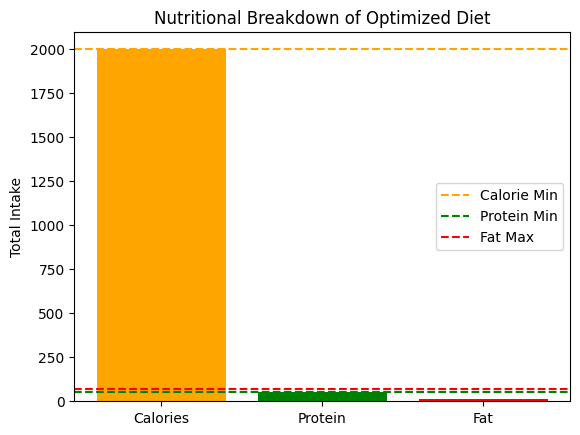

In [1]:
!pip install pulp matplotlib

import pulp
import pandas as pd
import matplotlib.pyplot as plt

# Defining food with cost and nutrition
data = {
    'Food': ['Chicken Breast', 'Rice', 'Broccoli', 'Milk', 'Eggs'],
    'Cost': [2.0, 0.5, 0.75, 0.6, 0.25]
}

# Define Food Data
data = {
    'Food': ['Chicken Breast', 'Rice', 'Broccoli', 'Milk', 'Eggs'],
    'Cost': [2.0, 0.5, 0.75, 0.6, 0.25], # $ per serving
    'Calories': [165, 206, 55, 103, 78],
    'Protein': [31, 4.2, 3.7, 8, 6],
    'Fat': [3.6, 0.4, 0.3, 2.4, 5.3]
}

df = pd.DataFrame(data).set_index('Food')
df

# Set Nutrition Constraints
cal_min = 2000
protein_min = 50
fat_max = 70

# Define Linear Program
prob = pulp.LpProblem("Diet Optimization", pulp.LpMinimize)

# Decision variables: servings of each food
servings = pulp.LpVariable.dicts("Servings", df.index, lowBound=0)

# Objective: Minimize total cost
prob += pulp.lpSum([servings[i] * df.loc[i, 'Cost'] for i in df.index]), "Total Cost"

# Constraints
prob += pulp.lpSum([servings[i] * df.loc[i, 'Calories'] for i in df.index]) >= cal_min, "Calorie Minimum"
prob += pulp.lpSum([servings[i] * df.loc[i, 'Protein'] for i in df.index]) >= protein_min, "Protein Minimum"
prob += pulp.lpSum([servings[i] * df.loc[i, 'Fat'] for i in df.index]) <= fat_max, "Fat Maximum"

# Solve the Problem
prob.solve()
print("Status:", pulp.LpStatus[prob.status])

# Display selected servings
solution = {i: servings[i].varValue for i in df.index if servings[i].varValue > 0}
print("\nOptimized Food Plan (servings):")
for food, amount in solution.items():
  print(f"{food}: {amount:.2f} servings")

# Total cost
print(f"\nTotal cost: ${pulp.value(prob.objective):.2f}")

# Visualize Nutrition Breakdown
nutrition_totals = {
    'Calories': sum(servings[i].varValue * df.loc[i, 'Calories'] for i in df.index),
    'Protein': sum(servings[i].varValue * df.loc[i, 'Protein'] for i in df.index),
    'Fat': sum(servings[i].varValue * df.loc[i, 'Fat'] for i in df.index),
}

# Plot
plt.bar(nutrition_totals.keys(), nutrition_totals.values(), color=['orange', 'green', 'red'])
plt.axhline(y=cal_min, color='orange', linestyle='--', label='Calorie Min')
plt.axhline(y=protein_min, color='green', linestyle='--', label='Protein Min')
plt.axhline(y=fat_max, color='red', linestyle='--', label='Fat Max')
plt.ylabel("Total Intake")
plt.title("Nutritional Breakdown of Optimized Diet")
plt.legend()
plt.show()